In [1]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request
from sklearn.decomposition import PCA

import pandas as pd
from sklearn.preprocessing import StandardScaler

In [2]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x7f97d643ac10>)

In [3]:
df_stars = pd.read_csv("stars.csv")
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [4]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

le = LabelEncoder()
# Assign unique integers from 0 to 5 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


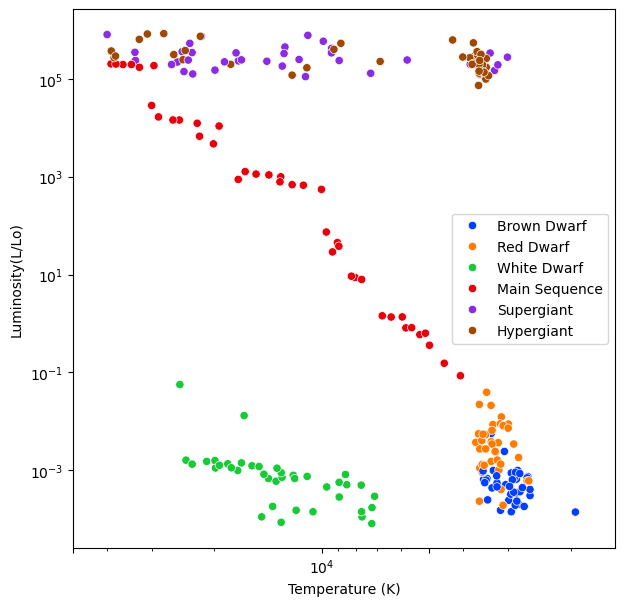

In [5]:
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels, palette='bright')

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

In [6]:
df_stars['Star type'][np.isnan(df_stars['Star type'])] #check

Series([], Name: Star type, dtype: int64)

(240, 4)
(4, 4)


<Axes: >

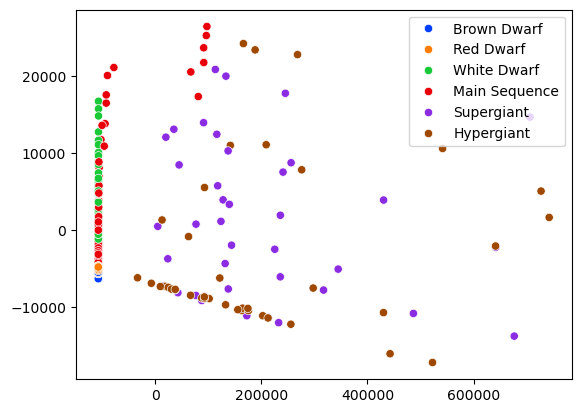

In [7]:
# NOT SCALED
X = np.array([df_stars['Temperature (K)'],df_stars['Absolute magnitude(Mv)'], df_stars['Radius(R/Ro)'], df_stars['Luminosity(L/Lo)']]).T
n_comp = 4
pca = PCA(n_components=n_comp) # n_components can be optionally set
pca.fit(X) 
projection = pca.fit_transform(X)




eigenvalues = pca.transform(X) # compute the subspace projection of X, 4 eigenvalues for each of the 100 samples
mean = pca.mean_ # length 10 mean of the data
eigenvectors = pca.components_ # 4x10 matrix of components, multiply each by respective eigenvalue to reconstruct

# Reconstruction of object1
# Xreconstruct[0] = mean + eigenvectors*eigenvalues[0]


print(eigenvalues.shape)
print(eigenvectors.shape)

sns.scatterplot(x=projection[:,0], y=projection[:,1], hue=labels, palette='bright')

In [8]:
evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

Expained fractional variance of data encapsulated in the eigenvalues: [9.97606313e-01 2.38789920e-03 5.78677260e-06 1.34274185e-09]


<Axes: >

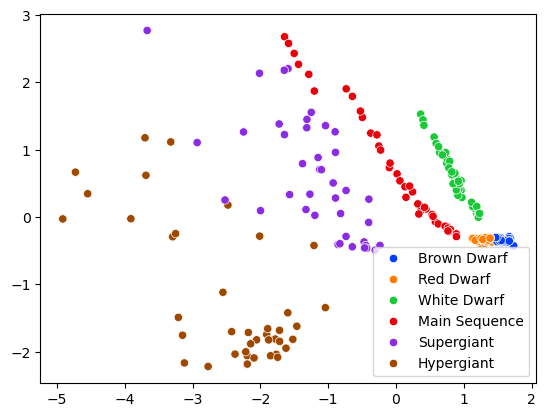

In [9]:
# SCALED
X = np.array([df_stars['Temperature (K)'], df_stars['Luminosity(L/Lo)'], df_stars['Radius(R/Ro)'],df_stars['Absolute magnitude(Mv)']]).T

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=n_comp)
projection = pca.fit_transform(X_scaled)

sns.scatterplot(x=projection[:,0], y=projection[:,1], hue=labels, palette='bright')

In [10]:
evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

Expained fractional variance of data encapsulated in the eigenvalues: [0.60357391 0.23500784 0.09329645 0.0681218 ]
